In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

### 1º QUESTÃO

In [161]:
# importing the exercise series. Download the data from Google Sheets in cvs format.

series = pd.read_csv('data_exercicio - Sheet 1 - data_exercicio.csv')
series = pd.DataFrame(series)
display(series)

,Unnamed: 0,time,ss1,ss2,ss3,ss4,ss5,ss6,ss7
0,1,101,"16,39326073","23,44865022","519,9475609","52,21743569","44,98942196","518,4486502","916,9196127"
1,2,102,"15,07310479","22,29242689","523,5923864","50,83946879","44,0347315","522,2924269","939,2120396"
2,3,103,"15,34479227","22,71484542","528,8429572","51,17794044","43,41654903","527,7148454","961,926885"
3,4,104,"13,86658909","21,39009016","532,3413428","49,73539114","42,47197045","531,3900902","983,3169751"
4,5,105,"13,86900751","21,53117447","537,3356002","49,90293634","41,42077503","536,5311745","1004,84815"
...,...,...,...,...,...,...,...,...,...
95,96,196,"10,8890157","27,77421347","991,134783","202,5400869","52,69093462","997,7742135","3112,837874"
96,97,197,"11,63098598","28,62507391","996,8629478","203,1369387","54,26038545","1003,625074","3141,462948"
97,98,198,"11,07110816","28,18150594","1001,282121","202,3796769","54,58259188","1008,181506","3169,644454"
98,99,199,"10,51362229","27,73473115","1005,709704","201,6949344","53,73660592","1012,734731","3197,379185"


O python não está fazendo a leitura correta de que os valores das séries são números. Por essa razão, vou trocar as vírgulas por pontos para que ele consiga ler como números.

In [164]:
# Lista das colunas numéricas
colunas_numericas = ['ss1', 'ss2', 'ss3', 'ss4', 'ss5', 'ss6', 'ss7']

# Troca as vírgulas por pontos e converte para float
for col in colunas_numericas:
    series[col] = series[col].str.replace(',', '.').astype(float)  # ou .astype(int) se não houver decimais

# Verifica o resultado
print(series.dtypes)

Unnamed: 0      int64
time            int64
ss1           float64
ss2           float64
ss3           float64
ss4           float64
ss5           float64
ss6           float64
ss7           float64
dtype: object


In [166]:
series.head()

,Unnamed: 0,time,ss1,ss2,ss3,ss4,ss5,ss6,ss7
0,1,101,16.393261,23.448650,519.947561,52.217436,44.989422,518.448650,916.919613
1,2,102,15.073105,22.292427,523.592386,50.839469,44.034731,522.292427,939.212040
2,3,103,15.344792,22.714845,528.842957,51.177940,43.416549,527.714845,961.926885
3,4,104,13.866589,21.390090,532.341343,49.735391,42.471970,531.390090,983.316975
4,5,105,13.869008,21.531174,537.335600,49.902936,41.420775,536.531175,1004.848150


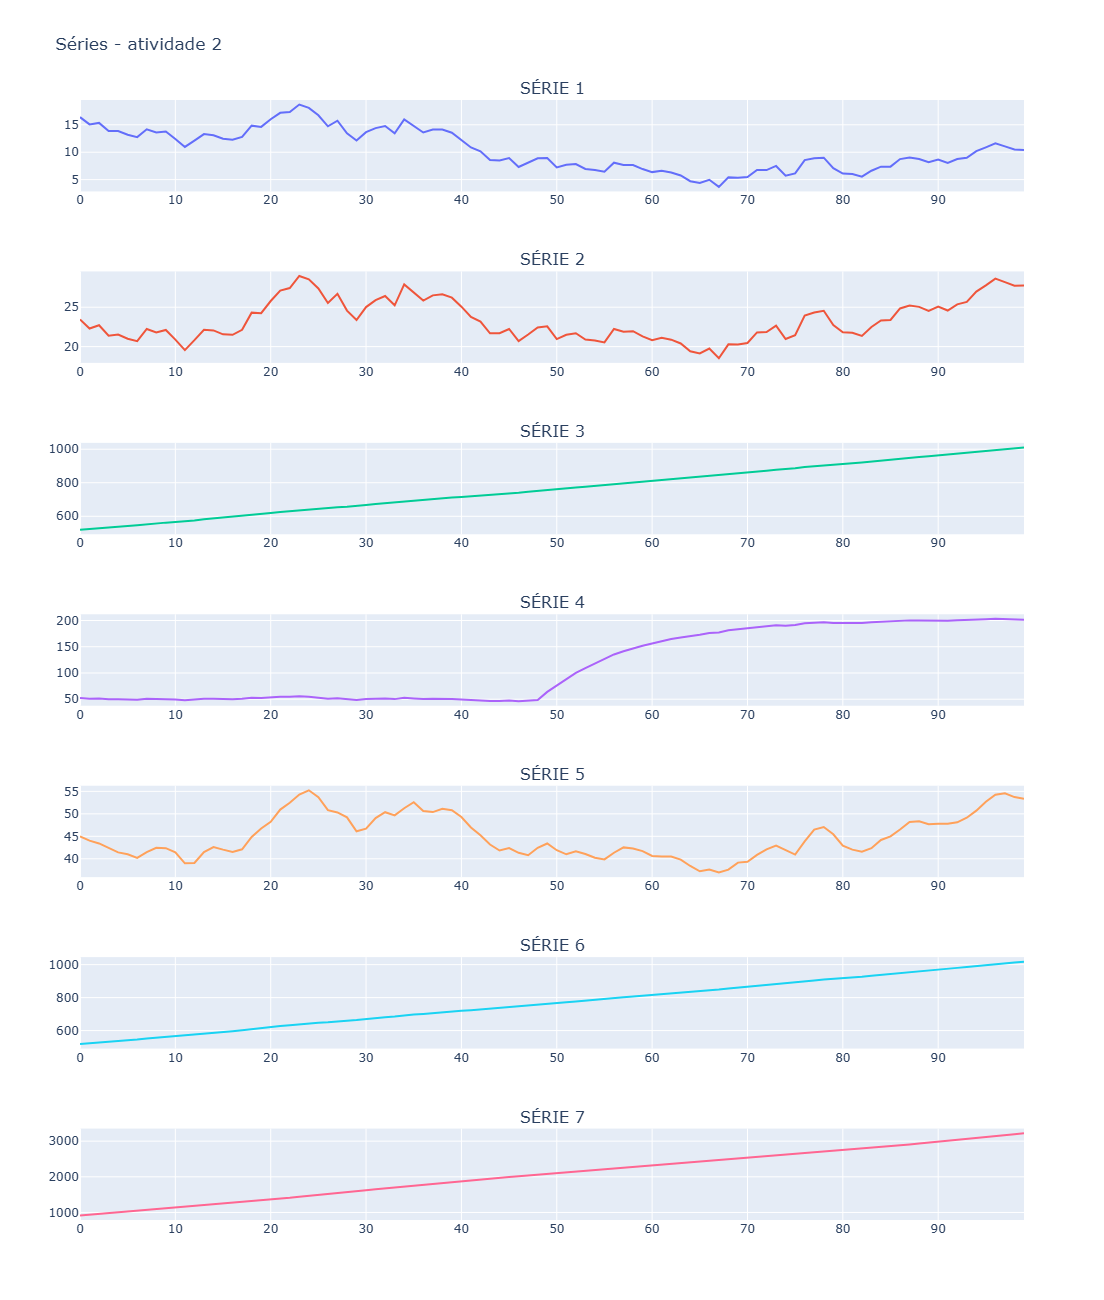

In [170]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criando a figura com subplots
fig = make_subplots(rows=7, cols=1, subplot_titles=('SÉRIE 1', 'SÉRIE 2', 'SÉRIE 3', 'SÉRIE 4','SÉRIE 5','SÉRIE 6','SÉRIE 7'))

# Adicionando as séries temporais aos subplots
fig.add_trace(go.Scatter(x=series.index, y=series['ss1'], name='Série 1'), row=1, col=1)
fig.add_trace(go.Scatter(x=series.index, y=series['ss2'], name='Série 2'), row=2, col=1)
fig.add_trace(go.Scatter(x=series.index, y=series['ss3'], name='Série 3'), row=3, col=1)
fig.add_trace(go.Scatter(x=series.index, y=series['ss4'], name='Série 4'), row=4, col=1)
fig.add_trace(go.Scatter(x=series.index, y=series['ss5'], name='Série 5'), row=5, col=1)
fig.add_trace(go.Scatter(x=series.index, y=series['ss6'], name='Série 6'), row=6, col=1)
fig.add_trace(go.Scatter(x=series.index, y=series['ss7'], name='Série 7'), row=7, col=1)

# Atualizando o layout da figura
fig.update_layout(height=1300, width=1000, title_text="Séries - atividade 2", showlegend=False)

# Exibindo a figura
fig.show()

### Augmented Dick-Fuller test (ADF)

**H0**: tem raíz unitária na série (série não estacionária)   
**H1**: não tem raíz unitária (série estacionária)

- Se P-valor < 5%, rejeitamos a hipótese nula (série estacionária)
- Se P-valor > 5%, não podemos rejeitar a nula (série não estacionária)

In [172]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(series['ss1'], 
               maxlag=None, 
               regression='c', 
               autolag='AIC', 
               store=False, 
               regresults=False)

# Exibindo os resultados
print('Estatística ADF:', adf_result[0])
print('Valor-p:', adf_result[1])
print('Valores Críticos:', adf_result[4])

Estatística ADF: -1.8616323982307583
Valor-p: 0.35031999563774113
Valores Críticos: {'1%': -3.498198082189098, '5%': -2.891208211860468, '10%': -2.5825959973472097}


In [174]:
resultados = {'série': ['ss1','ss2','ss3','ss4','ss5','ss6','ss7'],
              'Estatítistica ADF [-3.49 (1%)]': [-1.8616323982307583, -1.6137995122860909, 1.1365323899100839, -0.9902386548893919, -1.682067218850744, 0.7587061642886976, 0.6457789900455294],
              'P-valor': [0.35031999563774113, 0.47598143554791467, 0.9955166624293168, 0.7568078569820145, 0.4403748615544706, 0.9909395039455202, 0.9886912972933822],
              'Resultados': ['Raíz unitária', 'Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária']
             }

resultados_ADF = pd.DataFrame(resultados)
display(resultados_ADF)

,série,Estatítistica ADF [-3.49 (1%)],P-valor,Resultados
0,ss1,-1.861632,0.350320,Raíz unitária
1,ss2,-1.613800,0.475981,Raíz unitária
2,ss3,1.136532,0.995517,Raíz unitária
3,ss4,-0.990239,0.756808,Raíz unitária
4,ss5,-1.682067,0.440375,Raíz unitária
5,ss6,0.758706,0.990940,Raíz unitária
6,ss7,0.645779,0.988691,Raíz unitária


O resultado do teste de Dick-Fuller aumentado indica a presença de raíz unitária em todas as séries (séries não estacionárias). 

### KPSS test (Kwiatkowski-Phillips-Schmidt-Shin test for stationarity)

**H0**: x is level or trend stationary  
**H1**: x is not stationary

- p-value < 5%: reject the null hypothesis (not stationary)
- p-value > 5%: we cannot reject the null hypothesis (stationary)

In [176]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(series['ss1'], regression='c', nlags='auto', store=False)

print(kpss_result)
print('Estatística KPSS:', kpss_result[0])
print('Valor-p:', kpss_result[1])

(1.1461977128257552, 0.01, 5, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
Estatística KPSS: 1.1461977128257552
Valor-p: 0.01


C:\Users\KAWAN\AppData\Local\Temp\ipykernel_6824\452014511.py:3: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




In [178]:
resultados2 = {'série': ['ss1','ss2','ss3','ss4','ss5','ss6','ss7'],
              'Estatítistica KPSS [0,739 (1%)]': [1.1461977128257552, 0.18699057731489582, 1.7667600342782686, 1.5796394368028854, 0.18372518448965328, 1.7666016284351607, 1.7669569637456692],
              'P-valor': [0.01, 0.1, 0.01, 0.01, 0.1, 0.01, 0.01],
              'Resultados': ['Não estacionária', 'Estacionária','Não estacionária','Não estacionária','Estacionária','Não estacionária','Não Estacionária']
             }

resultados_KPSS = pd.DataFrame(resultados2)
display(resultados_KPSS)

,série,"Estatítistica KPSS [0,739 (1%)]",P-valor,Resultados
0,ss1,1.146198,0.01,Não estacionária
1,ss2,0.186991,0.10,Estacionária
2,ss3,1.766760,0.01,Não estacionária
3,ss4,1.579639,0.01,Não estacionária
4,ss5,0.183725,0.10,Estacionária
5,ss6,1.766602,0.01,Não estacionária
6,ss7,1.766957,0.01,Não Estacionária


O resultado do teste KPSS para as séries 2 e 5 indicam que estas são estacionárias. As demais séries (1, 3, 4, 6 e 7) indicaram não estacionariedade.

### Phillips Perron test

**H0**: there is a unit root  
**H1**: there is no unit root

If the p-value is above a critical size, then the null cannot be rejected that there and the series appears to be a unit root.

[Documentation Phillips Perron test](https://arch.readthedocs.io/en/latest/unitroot/generated/arch.unitroot.PhillipsPerron.html)

In [181]:
from arch.unitroot import PhillipsPerron

PP_result = PhillipsPerron(series['ss1'])

print(PP_result)

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -1.865
P-value                         0.349
Lags                               12
-------------------------------------

Trend: Constant
Critical Values: -3.50 (1%), -2.89 (5%), -2.58 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [183]:
resultados3 = {'série': ['ss1','ss2','ss3','ss4','ss5','ss6','ss7'],
              'Estatítistica do teste [-3.50 (1%)]': [-1.865, -1.746, 1.410, -0.296, -1.401, 0.892, 0.317],
              'P-valor': [0.349, 0.408, 0.997, 0.926, 0.582, 0.993, 0.978],
              'Resultados': ['Raíz unitária', 'Raíz unitária','Raíz unitária','Raíz unitária',
                             'Raíz unitária','Raíz unitária','Raíz unitária']
             }

resultados_PP = pd.DataFrame(resultados3)
display(resultados_PP)

,série,Estatítistica do teste [-3.50 (1%)],P-valor,Resultados
0,ss1,-1.865,0.349,Raíz unitária
1,ss2,-1.746,0.408,Raíz unitária
2,ss3,1.410,0.997,Raíz unitária
3,ss4,-0.296,0.926,Raíz unitária
4,ss5,-1.401,0.582,Raíz unitária
5,ss6,0.892,0.993,Raíz unitária
6,ss7,0.317,0.978,Raíz unitária


### Zivot-Andrews test

**H0**: existe raíz unitária com uma única quebra estrutural   
**H1**: a série é tendência estacionária ou quebra estacionária

- P-valor < 5% rejeita a nula
- P-valor > 5% não podemos rejeitar a nula

[Documentation Zivot-Andrews test (ARCH)](https://arch.readthedocs.io/en/latest/unitroot/generated/arch.unitroot.ZivotAndrews.html)

**Note**: The statsmodels also has the Zivot-Andrews test. I compared the results of both tests and they returned the same results. I choose the ARCH package because he returns a better interface of the results with a table.

In [185]:
from arch.unitroot import ZivotAndrews

ZA_result = ZivotAndrews(series['ss1'])

print(ZA_result)

        Zivot-Andrews Results        
Test Statistic                 -3.881
P-value                         0.426
Lags                                0
-------------------------------------

Trend: Constant
Critical Values: -5.28 (1%), -4.81 (5%), -4.57 (10%)
Null Hypothesis: The process contains a unit root with a single structural break.
Alternative Hypothesis: The process is trend and break stationary.


In [187]:
resultados4 = {'série': ['ss1','ss2','ss3','ss4','ss5','ss6','ss7'],
              'Estatítistica do teste [-5.28 (1%)]': [-3.881, -3.716, -3.952, -14.711, -3.015, -3.716, -3.514],
              'P-valor': [0.426, 0.536, 0.381, 0.000, 0.907, 0.536, 0.671],
              'Resultados': ['Raíz unitária', 'Raíz unitária','Raíz unitária','Raíz unitária',
                             'O processo é tendência e quebra estacionária','Raíz unitária','Raíz unitária']
             }

ZA_results = pd.DataFrame(resultados4)
display(ZA_results)

,série,Estatítistica do teste [-5.28 (1%)],P-valor,Resultados
0,ss1,-3.881,0.426,Raíz unitária
1,ss2,-3.716,0.536,Raíz unitária
2,ss3,-3.952,0.381,Raíz unitária
3,ss4,-14.711,0.000,Raíz unitária
4,ss5,-3.015,0.907,O processo é tendência e quebra estacionária
5,ss6,-3.716,0.536,Raíz unitária
6,ss7,-3.514,0.671,Raíz unitária


### Resultados gerais

In [189]:
results_geral = { 'Séries': ['ss1','ss2','ss3','ss4','ss5','ss6','ss7'],
                 'Resultado ADF': ['Raíz unitária', 'Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária'],
                 'Resultado KPSS': ['Não estacionária', 'Estacionária','Não estacionária','Não estacionária','Estacionária','Não estacionária','Não Estacionária'],
                 'Resultado PP': ['Raíz unitária', 'Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária','Raíz unitária'],
                 'Resultado ZA': ['Raíz unitária', 'Raíz unitária','Raíz unitária','O processo é tendência e quebra estacionária','Raíz unitária','Raíz unitária','Raíz unitária']
                }
res_geral = pd.DataFrame(results_geral)
display(res_geral)

,Séries,Resultado ADF,Resultado KPSS,Resultado PP,Resultado ZA
0,ss1,Raíz unitária,Não estacionária,Raíz unitária,Raíz unitária
1,ss2,Raíz unitária,Estacionária,Raíz unitária,Raíz unitária
2,ss3,Raíz unitária,Não estacionária,Raíz unitária,Raíz unitária
3,ss4,Raíz unitária,Não estacionária,Raíz unitária,O processo é tendência e quebra estacionária
4,ss5,Raíz unitária,Estacionária,Raíz unitária,Raíz unitária
5,ss6,Raíz unitária,Não estacionária,Raíz unitária,Raíz unitária
6,ss7,Raíz unitária,Não Estacionária,Raíz unitária,Raíz unitária


### 2º Questão

In [191]:
# importando a biblioteca do IPEA e verificando as duas primeiras séries

# Índice nacional de preços ao consumidor amplo (IPCA) geral: índice (dez. 1993 = 100) (PRECOS12_IPCA12)                 
# Produto interno bruto (PIB) a preços de mercado: índice real encadeado (média 1995 = 100) (SCN104_PIBPM104)

import ipeadatapy as ip 

# ip.describe('PRECOS12_IPCA12')
ip.describe('SCN104_PIBPM104')

,PIB - preços de mercado - índice real encadeado (média 1995 = 100)
Name,PIB - preços de mercado - índice real encadead...
Code,SCN104_PIBPM104
Big Theme,Macroeconômico
Theme code,8
Source,Instituto Brasileiro de Geografia e Estatístic...
Source acronym,IBGE/SCN Trim.
Comment,O produto interno bruto (PIB) é o total dos be...
Last update,2025-03-07T13:32:00.727-03:00
Frequency,Trimestral
Measure,-


In [193]:
# importando as séries

pib = ip.timeseries('SCN104_PIBPM104')
ipca = ip.timeseries('PRECOS12_IPCA12')

In [195]:
# salvando as séries como dataframe

pib = pd.DataFrame(pib)
ipca = pd.DataFrame(ipca)

In [197]:
# Valores das séries

print(pib, ipca)
# print(selicover)
# print(ipca)

                       CODE                   RAW DATE  DAY  MONTH  YEAR  \
DATE                                                                       
1996-01-01  SCN104_PIBPM104  1996-01-01T00:00:00-02:00    1      1  1996   
1996-04-01  SCN104_PIBPM104  1996-04-01T00:00:00-03:00    1      4  1996   
1996-07-01  SCN104_PIBPM104  1996-07-01T00:00:00-03:00    1      7  1996   
1996-10-01  SCN104_PIBPM104  1996-10-01T00:00:00-03:00    1     10  1996   
1997-01-01  SCN104_PIBPM104  1997-01-01T00:00:00-02:00    1      1  1997   
...                     ...                        ...  ...    ...   ...   
2023-10-01  SCN104_PIBPM104  2023-10-01T00:00:00-03:00    1     10  2023   
2024-01-01  SCN104_PIBPM104  2024-01-01T00:00:00-03:00    1      1  2024   
2024-04-01  SCN104_PIBPM104  2024-04-01T00:00:00-03:00    1      4  2024   
2024-07-01  SCN104_PIBPM104  2024-07-01T00:00:00-03:00    1      7  2024   
2024-10-01  SCN104_PIBPM104  2024-10-01T00:00:00-03:00    1     10  2024   

           

In [199]:
# criando uma variável data para o df da inflação

ipca['mes_ano'] = ipca['MONTH'].astype(str).str.zfill(2) + '/' + ipca['YEAR'].astype(str)
print(ipca)

                       CODE                   RAW DATE  DAY  MONTH  YEAR  \
DATE                                                                       
1979-12-01  PRECOS12_IPCA12  1979-12-01T00:00:00-02:00    1     12  1979   
1980-01-01  PRECOS12_IPCA12  1980-01-01T00:00:00-02:00    1      1  1980   
1980-02-01  PRECOS12_IPCA12  1980-02-01T00:00:00-02:00    1      2  1980   
1980-03-01  PRECOS12_IPCA12  1980-03-01T00:00:00-03:00    1      3  1980   
1980-04-01  PRECOS12_IPCA12  1980-04-01T00:00:00-03:00    1      4  1980   
...                     ...                        ...  ...    ...   ...   
2024-10-01  PRECOS12_IPCA12  2024-10-01T00:00:00-03:00    1     10  2024   
2024-11-01  PRECOS12_IPCA12  2024-11-01T00:00:00-03:00    1     11  2024   
2024-12-01  PRECOS12_IPCA12  2024-12-01T00:00:00-03:00    1     12  2024   
2025-01-01  PRECOS12_IPCA12  2025-01-01T00:00:00-03:00    1      1  2025   
2025-02-01  PRECOS12_IPCA12  2025-02-01T00:00:00-03:00    1      2  2025   

           

In [201]:
# Criar a coluna 'mes_ano' no formato 'MM/AAAA' (ex: '01/2020')
pib['mes_ano'] = pib['MONTH'].astype(str).str.zfill(2) + '/' + pib['YEAR'].astype(str)

# Mostrar o DataFrame
print(pib)

                       CODE                   RAW DATE  DAY  MONTH  YEAR  \
DATE                                                                       
1996-01-01  SCN104_PIBPM104  1996-01-01T00:00:00-02:00    1      1  1996   
1996-04-01  SCN104_PIBPM104  1996-04-01T00:00:00-03:00    1      4  1996   
1996-07-01  SCN104_PIBPM104  1996-07-01T00:00:00-03:00    1      7  1996   
1996-10-01  SCN104_PIBPM104  1996-10-01T00:00:00-03:00    1     10  1996   
1997-01-01  SCN104_PIBPM104  1997-01-01T00:00:00-02:00    1      1  1997   
...                     ...                        ...  ...    ...   ...   
2023-10-01  SCN104_PIBPM104  2023-10-01T00:00:00-03:00    1     10  2023   
2024-01-01  SCN104_PIBPM104  2024-01-01T00:00:00-03:00    1      1  2024   
2024-04-01  SCN104_PIBPM104  2024-04-01T00:00:00-03:00    1      4  2024   
2024-07-01  SCN104_PIBPM104  2024-07-01T00:00:00-03:00    1      7  2024   
2024-10-01  SCN104_PIBPM104  2024-10-01T00:00:00-03:00    1     10  2024   

           

In [203]:
# renomeando a coluna 'VALUE (-)

pib = pib.rename(columns={'VALUE (-)': 'value'})
print(pib)

                       CODE                   RAW DATE  DAY  MONTH  YEAR  \
DATE                                                                       
1996-01-01  SCN104_PIBPM104  1996-01-01T00:00:00-02:00    1      1  1996   
1996-04-01  SCN104_PIBPM104  1996-04-01T00:00:00-03:00    1      4  1996   
1996-07-01  SCN104_PIBPM104  1996-07-01T00:00:00-03:00    1      7  1996   
1996-10-01  SCN104_PIBPM104  1996-10-01T00:00:00-03:00    1     10  1996   
1997-01-01  SCN104_PIBPM104  1997-01-01T00:00:00-02:00    1      1  1997   
...                     ...                        ...  ...    ...   ...   
2023-10-01  SCN104_PIBPM104  2023-10-01T00:00:00-03:00    1     10  2023   
2024-01-01  SCN104_PIBPM104  2024-01-01T00:00:00-03:00    1      1  2024   
2024-04-01  SCN104_PIBPM104  2024-04-01T00:00:00-03:00    1      4  2024   
2024-07-01  SCN104_PIBPM104  2024-07-01T00:00:00-03:00    1      7  2024   
2024-10-01  SCN104_PIBPM104  2024-10-01T00:00:00-03:00    1     10  2024   

           

In [205]:
# renomeando a coluna 'VALUE (-)

ipca = ipca.rename(columns={'VALUE (-)': 'value'})
print(ipca)

                       CODE                   RAW DATE  DAY  MONTH  YEAR  \
DATE                                                                       
1979-12-01  PRECOS12_IPCA12  1979-12-01T00:00:00-02:00    1     12  1979   
1980-01-01  PRECOS12_IPCA12  1980-01-01T00:00:00-02:00    1      1  1980   
1980-02-01  PRECOS12_IPCA12  1980-02-01T00:00:00-02:00    1      2  1980   
1980-03-01  PRECOS12_IPCA12  1980-03-01T00:00:00-03:00    1      3  1980   
1980-04-01  PRECOS12_IPCA12  1980-04-01T00:00:00-03:00    1      4  1980   
...                     ...                        ...  ...    ...   ...   
2024-10-01  PRECOS12_IPCA12  2024-10-01T00:00:00-03:00    1     10  2024   
2024-11-01  PRECOS12_IPCA12  2024-11-01T00:00:00-03:00    1     11  2024   
2024-12-01  PRECOS12_IPCA12  2024-12-01T00:00:00-03:00    1     12  2024   
2025-01-01  PRECOS12_IPCA12  2025-01-01T00:00:00-03:00    1      1  2025   
2025-02-01  PRECOS12_IPCA12  2025-02-01T00:00:00-03:00    1      2  2025   

           

In [207]:
# vou fazer um recorte nos dados da inflação para pegar os dados a partir de janeiro de 1995

ipca2 = ipca[ipca['YEAR'] >= 1995]
print(ipca2)

                       CODE                   RAW DATE  DAY  MONTH  YEAR  \
DATE                                                                       
1995-01-01  PRECOS12_IPCA12  1995-01-01T00:00:00-02:00    1      1  1995   
1995-02-01  PRECOS12_IPCA12  1995-02-01T00:00:00-02:00    1      2  1995   
1995-03-01  PRECOS12_IPCA12  1995-03-01T00:00:00-03:00    1      3  1995   
1995-04-01  PRECOS12_IPCA12  1995-04-01T00:00:00-03:00    1      4  1995   
1995-05-01  PRECOS12_IPCA12  1995-05-01T00:00:00-03:00    1      5  1995   
...                     ...                        ...  ...    ...   ...   
2024-10-01  PRECOS12_IPCA12  2024-10-01T00:00:00-03:00    1     10  2024   
2024-11-01  PRECOS12_IPCA12  2024-11-01T00:00:00-03:00    1     11  2024   
2024-12-01  PRECOS12_IPCA12  2024-12-01T00:00:00-03:00    1     12  2024   
2025-01-01  PRECOS12_IPCA12  2025-01-01T00:00:00-03:00    1      1  2025   
2025-02-01  PRECOS12_IPCA12  2025-02-01T00:00:00-03:00    1      2  2025   

           

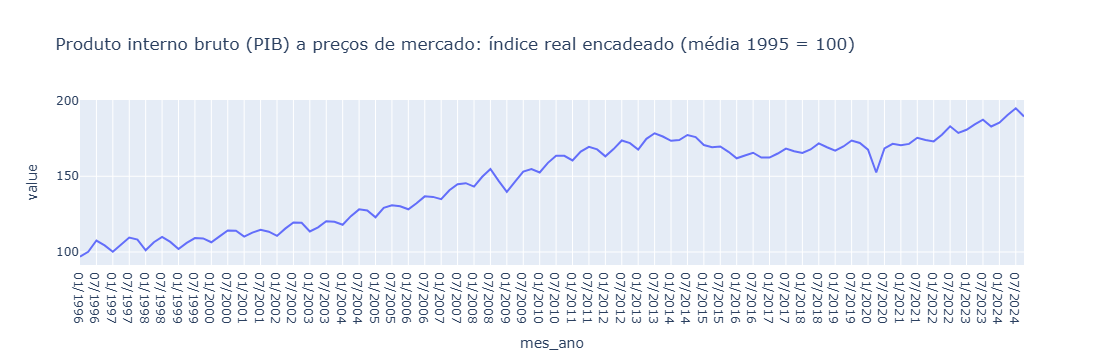

In [209]:
fig_pib = px.line(pib, x = 'mes_ano', y = 'value', title  = 'Produto interno bruto (PIB) a preços de mercado: índice real encadeado (média 1995 = 100)')
fig_pib.show()

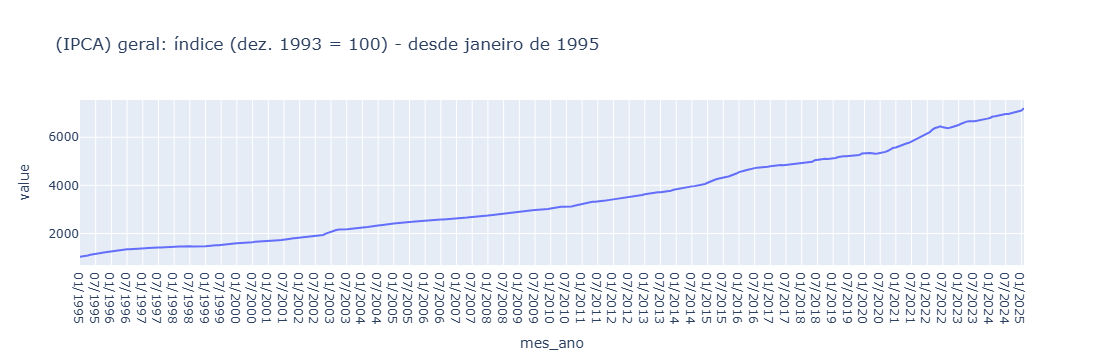

In [211]:
# gráfico da série de inflação após o corte de janeiro de 1995

fig_ipca2 = px.line(ipca2, x='mes_ano', y='value', title = '(IPCA) geral: índice (dez. 1993 = 100) - desde janeiro de 1995')
fig_ipca2.show()

### Testes para o PIB

In [213]:
### ADF 

from statsmodels.tsa.stattools import adfuller

adf_pib = adfuller(pib['value'], 
               maxlag=None, 
               regression='c', 
               autolag='AIC', 
               store=False, 
               regresults=False)

# Exibindo os resultados
print('Estatística ADF:', adf_pib[0])
print('Valor-p:', adf_pib[1])
print('Valores Críticos:', adf_pib[4])

Estatística ADF: -0.6533955960253479
Valor-p: 0.8584547657180588
Valores Críticos: {'1%': -3.490683082754047, '5%': -2.8879516565798817, '10%': -2.5808574442009578}


In [215]:
### KPSS

from statsmodels.tsa.stattools import kpss

kpss_pib = kpss(pib['value'], regression='c', nlags='auto', store=False)

print(kpss_pib)
print('Estatística KPSS:', kpss_pib[0])
print('Valor-p:', kpss_pib[1])

(1.6562095246941517, 0.01, 6, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
Estatística KPSS: 1.6562095246941517
Valor-p: 0.01


C:\Users\KAWAN\AppData\Local\Temp\ipykernel_6824\1433312275.py:5: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




In [217]:
### Phillips-Perron

from arch.unitroot import PhillipsPerron

PP_pib = PhillipsPerron(pib['value'])

print(PP_pib)

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -1.015
P-value                         0.748
Lags                               13
-------------------------------------

Trend: Constant
Critical Values: -3.49 (1%), -2.89 (5%), -2.58 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [219]:
### Zivot-Andrews

from arch.unitroot import ZivotAndrews

ZA_pib = ZivotAndrews(pib['value'])

print(ZA_pib)

        Zivot-Andrews Results        
Test Statistic                 -4.298
P-value                         0.193
Lags                                8
-------------------------------------

Trend: Constant
Critical Values: -5.28 (1%), -4.81 (5%), -4.57 (10%)
Null Hypothesis: The process contains a unit root with a single structural break.
Alternative Hypothesis: The process is trend and break stationary.


#### PIB stationary tests results

In [221]:
pib_stationary = { 'Description': ['Test statistic', 'Critical value (5%)', 'P-value', 'Test Result', 'Final result'],
                  'ADF': [-0.6533955960253479, -2.8879516565798817, 0.8584547657180588, 'Não podemos rejeitar a nula de que há raíz unitária', 'Não estacionária'],
                  'KPSS': [1.6562095246941517, 0.463, 0.01, 'Podemos rejeitar a nula de que a série é estacionária', 'Não estacionária'],
                  'Phillips Perron': [-1.015, -2.89, 0.748, 'Não podemos rejeitar a nula de que há raíz unitária', 'Não estacionária'],
                  'Zivot-Andrews': [-4.298, -4.81, 0.193, 'Não podemos rejeitar a nula que há raíz unitária com uma quebra estrutural', 'Não estacionária']
                 }

pib_stat = pd.DataFrame(pib_stationary)
display(pib_stat)

,Description,ADF,KPSS,Phillips Perron,Zivot-Andrews
0,Test statistic,-0.653396,1.65621,-1.015,-4.298
1,Critical value (5%),-2.887952,0.463,-2.89,-4.81
2,P-value,0.858455,0.01,0.748,0.193
3,Test Result,Não podemos rejeitar a nula de que há raíz uni...,Podemos rejeitar a nula de que a série é estac...,Não podemos rejeitar a nula de que há raíz uni...,Não podemos rejeitar a nula que há raíz unitár...
4,Final result,Não estacionária,Não estacionária,Não estacionária,Não estacionária


### Testes para o IPCA

In [223]:
### ADF 

from statsmodels.tsa.stattools import adfuller

adf_ipca = adfuller(ipca2['value'], 
               maxlag=None, 
               regression='c', 
               autolag='AIC', 
               store=False, 
               regresults=False)

# Exibindo os resultados
print('Estatística ADF:', adf_ipca[0])
print('Valor-p:', adf_ipca[1])
print('Valores Críticos:', adf_ipca[4])

Estatística ADF: 4.195211734228508
Valor-p: 1.0
Valores Críticos: {'1%': -3.448645946352023, '5%': -2.869602139060357, '10%': -2.5710650077160495}


In [225]:
### KPSS

from statsmodels.tsa.stattools import kpss

kpss_ipca = kpss(ipca2['value'], regression='c', nlags='auto', store=False)

print(kpss_ipca)
print('Estatística KPSS:', kpss_ipca[0])
print('Valor-p:', kpss_ipca[1])

(3.0210300581044125, 0.01, 11, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
Estatística KPSS: 3.0210300581044125
Valor-p: 0.01


C:\Users\KAWAN\AppData\Local\Temp\ipykernel_6824\768017144.py:5: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




In [227]:
### Phillips-Perron

from arch.unitroot import PhillipsPerron

PP_ipca = PhillipsPerron(ipca2['value'])

print(PP_ipca)

     Phillips-Perron Test (Z-tau)    
Test Statistic                  4.254
P-value                         1.000
Lags                               17
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [229]:
### Zivot - Andrews

from arch.unitroot import ZivotAndrews

ZA_ipca = ZivotAndrews(ipca2['value'])

print(ZA_ipca)

        Zivot-Andrews Results        
Test Statistic                 -2.230
P-value                         0.993
Lags                                1
-------------------------------------

Trend: Constant
Critical Values: -5.28 (1%), -4.81 (5%), -4.57 (10%)
Null Hypothesis: The process contains a unit root with a single structural break.
Alternative Hypothesis: The process is trend and break stationary.


#### IPCA stationaty tests results

In [231]:
ipca_stationary = { 'Description': ['Test statistic', 'Critical value (5%)','P-value', 'Test Result', 'Final result'],
                  'ADF': [4.195211734228508, -2.869602139060357, 1.0, 'Não podemos rejeitar a nula de que há raíz unitária', 'Não estacionária'],
                  'KPSS': [3.0210300581044125, 0.463, 0.01, 'Podemos rejeitar a nula de que a série é estacionária', 'Não estacionária'],
                  'Phillips Perron': [4.254, -2.87, 1.000, 'Não podemos rejeitar a nula de que há raíz unitária', 'Não estacionária'],
                  'Zivot-Andrews': [-2.230, -4.81,  0.993, 'Não podemos rejeitar a nula que há raíz unitária com uma quebra estrutural', 'Não estacionária']
                 }

ipca_stat = pd.DataFrame(ipca_stationary)
display(ipca_stat)

,Description,ADF,KPSS,Phillips Perron,Zivot-Andrews
0,Test statistic,4.195212,3.02103,4.254,-2.23
1,Critical value (5%),-2.869602,0.463,-2.87,-4.81
2,P-value,1.0,0.01,1.0,0.993
3,Test Result,Não podemos rejeitar a nula de que há raíz uni...,Podemos rejeitar a nula de que a série é estac...,Não podemos rejeitar a nula de que há raíz uni...,Não podemos rejeitar a nula que há raíz unitár...
4,Final result,Não estacionária,Não estacionária,Não estacionária,Não estacionária
